# Phase 3.3: Informativeness Comparison — GC vs PDC

**Tujuan:**  
Membandingkan secara kuantitatif seberapa **informatif** fitur-fitur dari
metode **GC** vs **6 band PDC** untuk klasifikasi emosi.

**Metrik perbandingan:**
1. **Jumlah fitur yang lolos seleksi** — setelah zero-var & multicollinearity removal
2. **Mean F-Score** — rata-rata diskriminasi fitur terhadap kelas emosi
3. **Mean Mutual Information** — rata-rata informasi bersama fitur-target
4. **Baseline Classification Accuracy** — akurasi RF sederhana (5-Fold CV)
5. **Tabel ringkasan** — siapa pemenang per kriteria?

**Input:** CSV dari Phase 1 (fitur dihitung ulang inline)  
**Output:** CSV & gambar perbandingan informativeness

---

In [1]:
# ============================================================
# SEL INI: IMPORT LIBRARY & KONFIGURASI
# ------------------------------------------------------------
# Notebook ini membandingkan informativeness GC vs PDC (6 band) vs
# Spectral menggunakan fitur REDUCED hasil Phase 3.1
# (engineered_features_*.csv - graph-metric + derived + spectral,
# TANPA raw edge_ yang menyebabkan p >> n). Sebelumnya notebook ini
# memuat langsung dari Phase 1 (cleaned_graph_metrics_*.csv, MASIH
# include edges) sehingga baseline CV Accuracy di bawah computed pada
# ~3500-3900 fitur/metode -- correlation-filter jadi lambat & baseline
# akurasi lebih rendah karena rasio p/n masih buruk.
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.facecolor'] = 'white'

FEAT_DIR   = Path(r'D:\Skripsi\new_data\phase_3_feature_engineering\csv')
OUTPUT_DIR = Path(r'D:\Skripsi\new_data\phase_3_feature_engineering\3.3_informativeness_comparison\output')
FIG_DIR    = Path(r'D:\Skripsi\new_data\phase_3_feature_engineering\3.3_informativeness_comparison\figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

CLASS_COL = 'class_label'
TARGET    = 'class'
EMOTIONS  = ['negative', 'neutral', 'positive']
ID_COLS   = ['subject_id','subject_num','session','trial','class','class_label']

DATASETS = {
    'GC'           : FEAT_DIR / 'engineered_features_gc.csv',
    'PDC Delta'    : FEAT_DIR / 'engineered_features_pdc_delta.csv',
    'PDC Theta'    : FEAT_DIR / 'engineered_features_pdc_theta.csv',
    'PDC Alpha'    : FEAT_DIR / 'engineered_features_pdc_alpha.csv',
    'PDC Beta'     : FEAT_DIR / 'engineered_features_pdc_beta.csv',
    'PDC Gamma'    : FEAT_DIR / 'engineered_features_pdc_gamma.csv',
    'PDC Broadband': FEAT_DIR / 'engineered_features_pdc_broadband.csv',
    'Spectral'     : FEAT_DIR / 'engineered_features_spectral.csv',
}
print('Libraries loaded. Ready.')


Libraries loaded. Ready.


---
## 1. Load Data & Feature Engineering (inline)

Memuat CSV dari Phase 1, menambahkan fitur turunan (Phase 3.1),
lalu menjalankan filtering (Phase 3.2) secara inline.

In [2]:
# ============================================================
# SEL INI: LOAD DATA (REDUCED, Phase 3.1) + FILTERING (Phase 3.2 inline)
# ------------------------------------------------------------
# File engineered_features_*.csv dari Phase 3.1 SUDAH:
#   - Prefix di-strip, kolom generik
#   - Fitur turunan (DI/ratio/peak/log/zsub/interaction) ditambahkan
#   - Raw edge-level (_edge_) DIBUANG (fix p>>n, lihat Phase 3.1)
# Jadi di sini tinggal jalankan filtering (Phase 3.2):
#   1) Buang zero-variance
#   2) Buang multicollinear (|r| > 0.95)
# ============================================================
def load_and_prepare(name, csv_path):
    df = pd.read_csv(csv_path)

    feat_cols = [c for c in df.columns if c not in ID_COLS
                 and c != 'hub_channel'
                 and df[c].dtype in ['float64','int64']]
    # 1. Zero-var
    feat_cols = [c for c in feat_cols if df[c].std() >= 1e-10]
    # 2. Multicollinearity
    corr = df[feat_cols].corr().abs()
    to_drop = set()
    for i in range(len(feat_cols)):
        for j in range(i+1, len(feat_cols)):
            if corr.iloc[i,j] > 0.95:
                mi = corr.iloc[i].drop(feat_cols[i]).mean()
                mj = corr.iloc[j].drop(feat_cols[j]).mean()
                to_drop.add(feat_cols[i] if mi > mj else feat_cols[j])
    feat_cols = [c for c in feat_cols if c not in to_drop]
    return df, feat_cols

prepared = {}
for name, csv_path in DATASETS.items():
    df, feat_cols = load_and_prepare(name, csv_path)
    prepared[name] = {'df': df, 'features': feat_cols}
    print(f'  {name:<15} {len(feat_cols)} fitur siap')


  GC              261 fitur siap


  PDC Delta       175 fitur siap


  PDC Theta       174 fitur siap


  PDC Alpha       175 fitur siap


  PDC Beta        178 fitur siap


  PDC Gamma       185 fitur siap


  PDC Broadband   181 fitur siap


  Spectral        382 fitur siap


---
## 2. Hitung Skor Informativeness Per Metode

Untuk setiap metode, hitung:
- **Mean F-Score** — rata-rata ANOVA F-value seluruh fitur
- **Max F-Score** — F-value tertinggi (fitur terbaik)
- **Mean MI** — rata-rata Mutual Information
- **Max MI** — MI tertinggi
- **5-Fold CV Accuracy** — akurasi baseline Random Forest

In [3]:
# ============================================================
# SEL INI: HITUNG SKOR INFORMATIVENESS PER METODE
# ------------------------------------------------------------
# Menghitung 5 metrik informativeness untuk setiap metode:
#   1) F-Score (ANOVA F-value) — mean & max
#   2) Mutual Information — mean & max
#   3) Baseline Accuracy (RF 5-Fold CV)
#
# Semua skor dihitung pada fitur yang sudah difilter (tidak
# ada zero-variance atau multikolinearitas tinggi).
# Target = kolom 'class' (numerik 0/1/2).
# ============================================================
results = []
# FIX: StratifiedGroupKFold (bukan StratifiedKFold biasa) -- data ini 675 baris
# = 15 subjek x 45 trial, EEG sangat subject-specific. Tanpa grouping per
# subject_id, trial subjek yang sama bisa nyasar ke train & test fold sekaligus,
# membuat 'Baseline CV Accuracy' inflasi dan bias kesimpulan GC vs PDC di bawah.
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

for name, info in prepared.items():
    df        = info['df']
    feat_cols = info['features']
    X = df[feat_cols].values
    y = df[TARGET].values
    groups = df['subject_id'].values

    scaler = StandardScaler()
    X_s    = scaler.fit_transform(X)

    # F-Score
    f_scores, f_pvals = f_classif(X_s, y)
    n_sig = (f_pvals < 0.05).sum()

    # Mutual Information (rata-rata 5 run)
    mi_scores = np.mean([
        mutual_info_classif(X_s, y, random_state=s)
        for s in range(5)
    ], axis=0)

    # Baseline Classification (RF Grouped 5-Fold CV, held-out subjects)
    rf = RandomForestClassifier(
        n_estimators=200, max_depth=10,
        random_state=42, n_jobs=-1,
    )
    cv_scores = cross_val_score(rf, X_s, y, groups=groups, cv=cv, scoring='accuracy')

    results.append({
        'method'      : name,
        'n_features'  : len(feat_cols),
        'n_significant': n_sig,
        'mean_f_score': round(float(np.mean(f_scores)), 4),
        'max_f_score' : round(float(np.max(f_scores)), 4),
        'mean_mi'     : round(float(np.mean(mi_scores)), 4),
        'max_mi'      : round(float(np.max(mi_scores)), 4),
        'cv_accuracy_mean': round(float(cv_scores.mean()), 4),
        'cv_accuracy_std' : round(float(cv_scores.std()), 4),
    })
    print(f'  {name:<15} F={np.mean(f_scores):.2f} '
          f'MI={np.mean(mi_scores):.4f} '
          f'Acc={cv_scores.mean():.4f}±{cv_scores.std():.4f}')

info_df = pd.DataFrame(results)
info_df.to_csv(OUTPUT_DIR / 'informativeness_comparison.csv', index=False)
print(f'\nSaved: informativeness_comparison.csv')


  GC              F=8.72 MI=0.0249 Acc=0.5378±0.0776


  PDC Delta       F=4.25 MI=0.0144 Acc=0.4756±0.0342


  PDC Theta       F=4.30 MI=0.0147 Acc=0.4504±0.0541


  PDC Alpha       F=4.31 MI=0.0164 Acc=0.4933±0.0374


  PDC Beta        F=3.91 MI=0.0157 Acc=0.4904±0.0615


  PDC Gamma       F=3.63 MI=0.0141 Acc=0.4859±0.0605


  PDC Broadband   F=3.97 MI=0.0177 Acc=0.4741±0.0635


  Spectral        F=8.01 MI=0.0343 Acc=0.5333±0.0248

Saved: informativeness_comparison.csv


---
## 3. Tabel Perbandingan Komprehensif

Satu tabel ringkas membandingkan semua metrik informativeness antar metode.

In [4]:
# ============================================================
# SEL INI: TABEL PERBANDINGAN KOMPREHENSIF
# ------------------------------------------------------------
# Menampilkan tabel lengkap metrik informativeness untuk
# semua 7 metode, dengan tanda 'WINNER' pada metode terbaik
# di setiap kolom metrik.
# ============================================================
print('TABEL PERBANDINGAN INFORMATIVENESS')
print('='*95)
print(f'  {"Method":<15} {"#Feat":>6} {"#Sig":>5} {"Mean F":>8} '
      f'{"Max F":>8} {"Mean MI":>8} {"Max MI":>8} {"CV Acc":>12}')
print('  '+'-'*85)

# Tandai pemenang per kolom
winners = {
    'n_features'   : info_df.loc[info_df['n_features'].idxmax(),   'method'],
    'n_significant': info_df.loc[info_df['n_significant'].idxmax(),'method'],
    'mean_f_score' : info_df.loc[info_df['mean_f_score'].idxmax(), 'method'],
    'max_f_score'  : info_df.loc[info_df['max_f_score'].idxmax(),  'method'],
    'mean_mi'      : info_df.loc[info_df['mean_mi'].idxmax(),      'method'],
    'max_mi'       : info_df.loc[info_df['max_mi'].idxmax(),       'method'],
    'cv_accuracy_mean': info_df.loc[info_df['cv_accuracy_mean'].idxmax(),'method'],
}

for _, row in info_df.iterrows():
    acc = f'{row["cv_accuracy_mean"]:.4f}±{row["cv_accuracy_std"]:.4f}'
    print(f'  {row["method"]:<15} {row["n_features"]:>6} {row["n_significant"]:>5} '
          f'{row["mean_f_score"]:>8.2f} {row["max_f_score"]:>8.2f} '
          f'{row["mean_mi"]:>8.4f} {row["max_mi"]:>8.4f} {acc:>12}')

print(f'\n  --- PEMENANG ---')
for col, winner in winners.items():
    print(f'    {col:<20}: {winner}')


TABEL PERBANDINGAN INFORMATIVENESS
  Method           #Feat  #Sig   Mean F    Max F  Mean MI   Max MI       CV Acc
  -------------------------------------------------------------------------------------
  GC                 261   157     8.72    56.86   0.0249   0.1276 0.5378±0.0776
  PDC Delta          175    55     4.25    60.91   0.0144   0.0876 0.4756±0.0342
  PDC Theta          174    58     4.30    57.95   0.0147   0.1093 0.4504±0.0541
  PDC Alpha          175    47     4.31    56.93   0.0164   0.0873 0.4933±0.0374
  PDC Beta           178    46     3.91    48.50   0.0157   0.0968 0.4904±0.0615
  PDC Gamma          185    49     3.63    49.68   0.0141   0.0829 0.4859±0.0605
  PDC Broadband      181    50     3.97    53.41   0.0177   0.0867 0.4741±0.0635
  Spectral           382   177     8.01   139.36   0.0343   0.1663 0.5333±0.0248

  --- PEMENANG ---
    n_features          : Spectral
    n_significant       : Spectral
    mean_f_score        : GC
    max_f_score         : Spec

---
## 4. Visualisasi: Grouped Bar Chart

Perbandingan visual metrik informativeness antar semua 7 metode.

Saved: D:\Skripsi\new_data\phase_3_feature_engineering\3.3_informativeness_comparison\figures\informativeness_bars.png


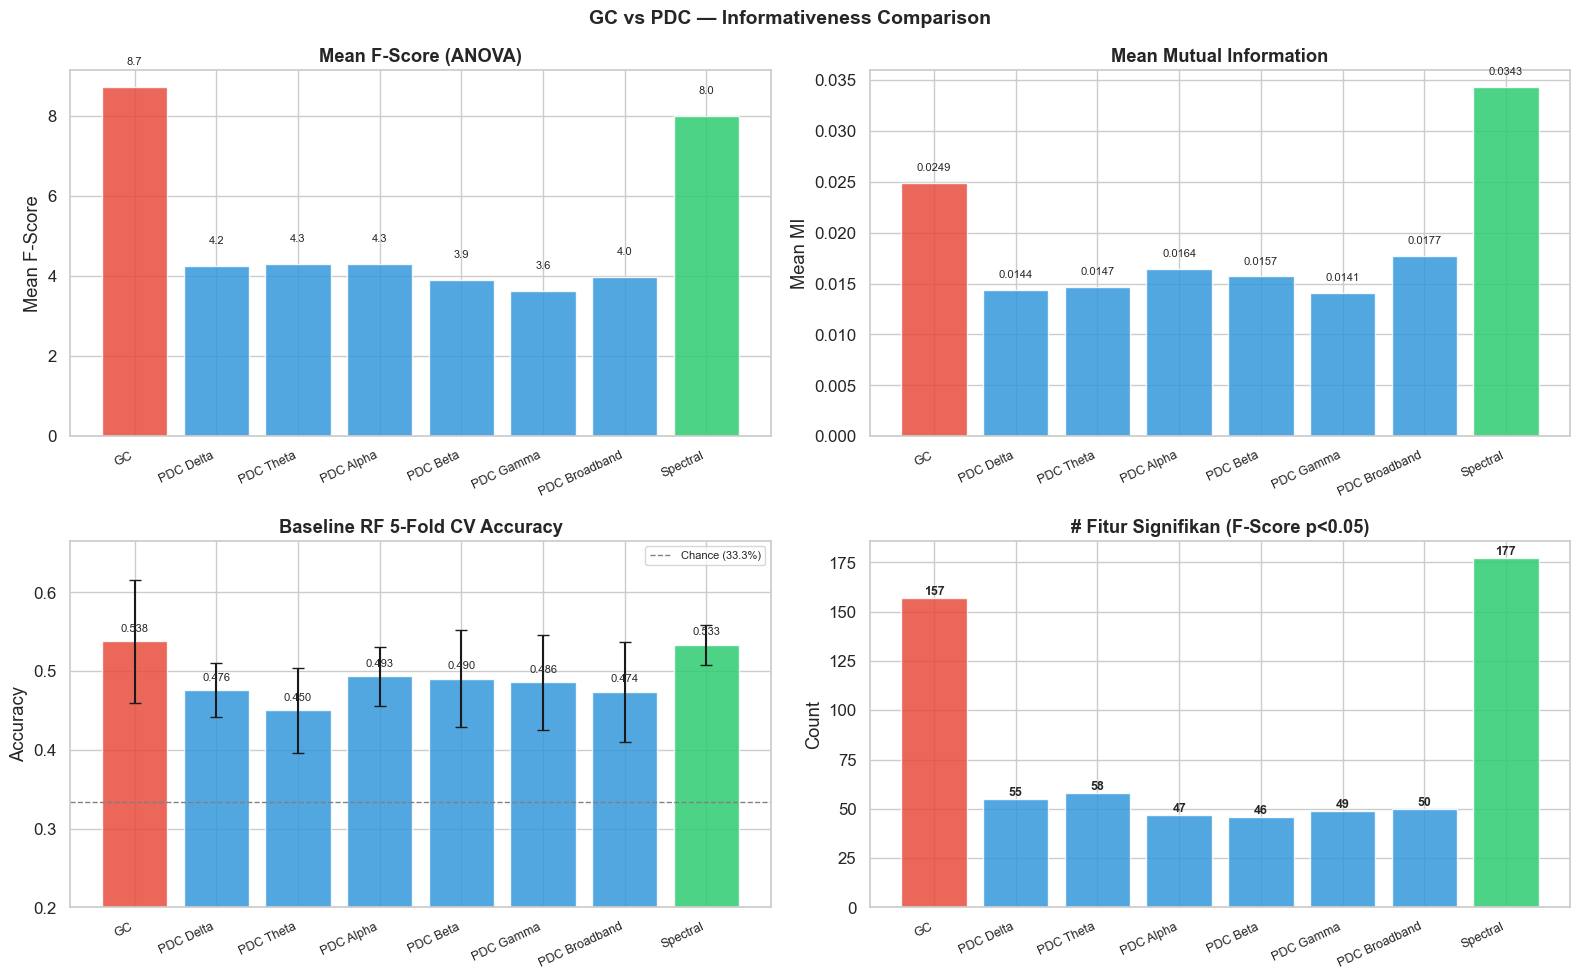

In [5]:
# ============================================================
# SEL INI: GROUPED BAR CHART INFORMATIVENESS
# ------------------------------------------------------------
# 4 subplot menampilkan perbandingan antar metode:
#   1) Mean F-Score
#   2) Mean Mutual Information
#   3) 5-Fold CV Accuracy (dengan error bar std)
#   4) Jumlah fitur signifikan (F p<0.05)
#
# Warna merah untuk GC, biru untuk PDC bands.
# Output: informativeness_bars.png
# ============================================================
methods = info_df['method'].tolist()
x       = np.arange(len(methods))
colors  = ['#e74c3c'] + ['#3498db']*6 + ['#2ecc71']  # GC merah, PDC biru, Spectral hijau

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Mean F-Score
ax = axes[0,0]
bars = ax.bar(x, info_df['mean_f_score'], color=colors, alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(methods, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Mean F-Score'); ax.set_title('Mean F-Score (ANOVA)', fontweight='bold')
for bar, val in zip(bars, info_df['mean_f_score']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=8)

# 2. Mean MI
ax = axes[0,1]
bars = ax.bar(x, info_df['mean_mi'], color=colors, alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(methods, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Mean MI'); ax.set_title('Mean Mutual Information', fontweight='bold')
for bar, val in zip(bars, info_df['mean_mi']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8)

# 3. CV Accuracy
ax = axes[1,0]
bars = ax.bar(x, info_df['cv_accuracy_mean'], yerr=info_df['cv_accuracy_std'],
              color=colors, alpha=0.85, edgecolor='white', capsize=4)
ax.set_xticks(x); ax.set_xticklabels(methods, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Accuracy'); ax.set_title('Baseline RF 5-Fold CV Accuracy', fontweight='bold')
ymax = max(0.55, info_df['cv_accuracy_mean'].max() + info_df['cv_accuracy_std'].max() + 0.05)
ax.set_ylim(0.20, ymax)  # chance = 0.333, auto-scale kalau akurasi baru lebih tinggi
ax.axhline(y=1/3, color='gray', linestyle='--', linewidth=1, label='Chance (33.3%)')
ax.legend(fontsize=8)
for bar, val in zip(bars, info_df['cv_accuracy_mean']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# 4. N Significant
ax = axes[1,1]
bars = ax.bar(x, info_df['n_significant'], color=colors, alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(methods, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Count'); ax.set_title('# Fitur Signifikan (F-Score p<0.05)', fontweight='bold')
for bar, val in zip(bars, info_df['n_significant']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.suptitle('GC vs PDC — Informativeness Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
p = FIG_DIR / 'informativeness_bars.png'
fig.savefig(p, dpi=150, bbox_inches='tight', facecolor='white')
print(f'Saved: {p}')
plt.show()


---
## 5. Radar Chart — Profil Informativeness

Radar chart menampilkan profil informativeness setiap metode
secara multi-dimensi. Metode dengan area radar lebih luas = lebih informatif.

Saved: D:\Skripsi\new_data\phase_3_feature_engineering\3.3_informativeness_comparison\figures\informativeness_radar.png


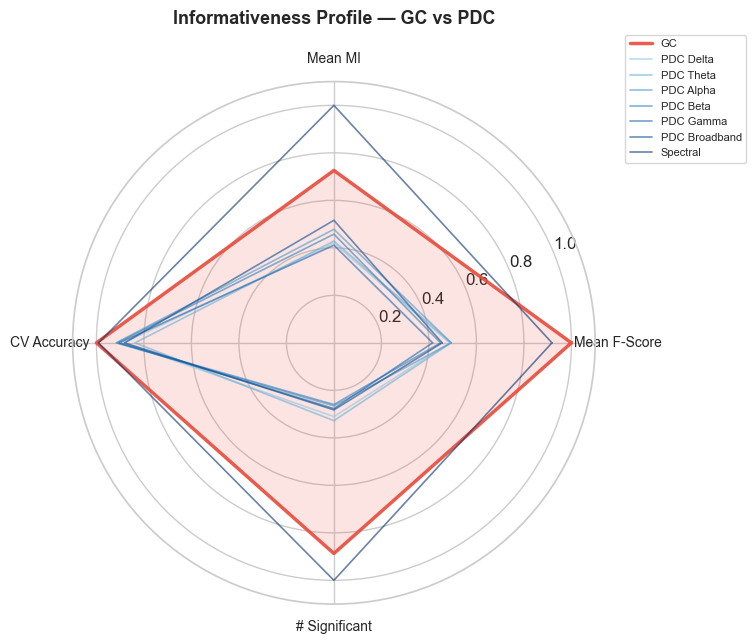

In [6]:
# ============================================================
# SEL INI: RADAR CHART PROFIL INFORMATIVENESS
# ------------------------------------------------------------
# Setiap metode ditampilkan sebagai polygon pada radar chart
# dengan 4 sumbu:
#   - Mean F-Score (dinormalisasi ke [0,1])
#   - Mean MI (dinormalisasi ke [0,1])
#   - CV Accuracy (dinormalisasi ke [0,1])
#   - # Fitur Signifikan (dinormalisasi ke [0,1])
#
# Metode dengan area polygon lebih luas = lebih informatif
# secara keseluruhan.
# Output: informativeness_radar.png
# ============================================================
categories = ['Mean F-Score', 'Mean MI', 'CV Accuracy', '# Significant']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # tutup polygon

# Normalisasi setiap metrik ke [0,1]
norm_data = info_df.copy()
for col in ['mean_f_score', 'mean_mi', 'cv_accuracy_mean', 'n_significant']:
    mx = norm_data[col].max()
    norm_data[col+'_norm'] = norm_data[col] / mx if mx > 0 else 0.0

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Warna per metode
import matplotlib.cm as cm
method_colors = {'GC': '#e74c3c'}
pdc_names = [n for n in methods if n != 'GC']
for i, n in enumerate(pdc_names):
    method_colors[n] = cm.Blues(0.4 + i * 0.1)

for _, row in norm_data.iterrows():
    values = [
        row['mean_f_score_norm'],
        row['mean_mi_norm'],
        row['cv_accuracy_mean_norm'],
        row['n_significant_norm'],
    ]
    values += values[:1]
    lw = 2.5 if row['method'] == 'GC' else 1.2
    alpha = 0.9 if row['method'] == 'GC' else 0.6
    ax.plot(angles, values, linewidth=lw, label=row['method'],
            color=method_colors[row['method']], alpha=alpha)
    if row['method'] == 'GC':
        ax.fill(angles, values, alpha=0.15, color='#e74c3c')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_title('Informativeness Profile — GC vs PDC',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)

plt.tight_layout()
p = FIG_DIR / 'informativeness_radar.png'
fig.savefig(p, dpi=150, bbox_inches='tight', facecolor='white')
print(f'Saved: {p}')
plt.show()


---
## 6. Heatmap — Skor Per Fitur Per Metode

Heatmap detail menampilkan F-Score setiap fitur individu di setiap metode.
Ini membantu mengidentifikasi fitur mana yang konsisten informatif lintas metode.

Saved: D:\Skripsi\new_data\phase_3_feature_engineering\3.3_informativeness_comparison\figures\feature_fscore_heatmap.png


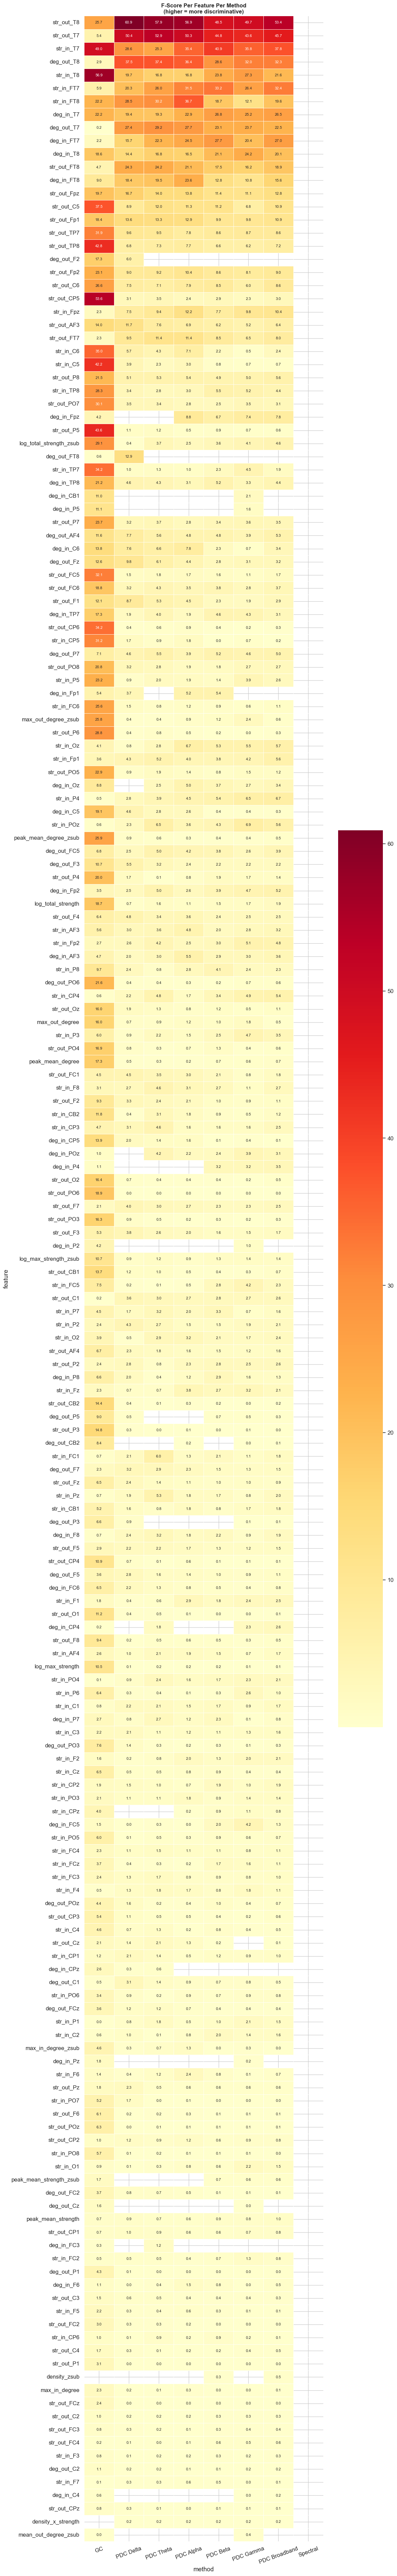

In [7]:
# ============================================================
# SEL INI: HEATMAP F-SCORE PER FITUR PER METODE
# ------------------------------------------------------------
# Membuat heatmap yang menampilkan F-Score setiap fitur
# (baris) di setiap metode (kolom). Hanya fitur yang muncul
# di minimal 2 metode yang ditampilkan.
#
# Warna kuning = F-Score tinggi (fitur diskriminatif)
# Warna biru   = F-Score rendah atau N/A
# Output: feature_fscore_heatmap.png
# ============================================================
rows = []
for name, info in prepared.items():
    df = info['df']
    feat_cols = info['features']
    X = df[feat_cols].values
    y = df[TARGET].values
    X_s = StandardScaler().fit_transform(X)
    f_scores, _ = f_classif(X_s, y)
    for feat, score in zip(feat_cols, f_scores):
        rows.append({'method': name, 'feature': feat, 'f_score': score})

detail_df = pd.DataFrame(rows)
detail_df.to_csv(OUTPUT_DIR / 'feature_detail_scores.csv', index=False)

# Pivot
pivot = detail_df.pivot_table(index='feature', columns='method',
                              values='f_score', aggfunc='first')
# Hanya fitur yang muncul di >= 2 metode
pivot = pivot.dropna(thresh=2)
# Urutkan berdasarkan mean F-Score
pivot['avg'] = pivot.mean(axis=1)
pivot = pivot.sort_values('avg', ascending=False).drop(columns='avg')

# Reorder kolom
col_order = [n for n in DATASETS.keys() if n in pivot.columns]
pivot = pivot[col_order]

fig, ax = plt.subplots(figsize=(max(12, len(col_order)*1.5),
                                max(6, len(pivot)*0.4)))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size':8})
ax.set_title('F-Score Per Feature Per Method\n(higher = more discriminative)',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
p = FIG_DIR / 'feature_fscore_heatmap.png'
fig.savefig(p, dpi=150, bbox_inches='tight', facecolor='white')
print(f'Saved: {p}')
plt.show()


---
## 7. Ringkasan & Kesimpulan

In [8]:
# ============================================================
# SEL INI: RINGKASAN AKHIR PHASE 3.3
# ------------------------------------------------------------
# Menampilkan kesimpulan akhir dari perbandingan GC vs PDC:
# siapa yang menang di setiap kriteria informativeness, dan
# kesimpulan keseluruhan untuk Bab 4 skripsi.
# ============================================================
print('='*65)
print('PHASE 3.3 COMPLETE — Informativeness Comparison')
print('='*65)

print(f'\n--- PEMENANG PER KRITERIA ---')
criteria = [
    ('Jumlah Fitur Tersedia',   'n_features',       'max'),
    ('Fitur Signifikan (p<0.05)','n_significant',   'max'),
    ('Mean F-Score',            'mean_f_score',     'max'),
    ('Max F-Score',             'max_f_score',      'max'),
    ('Mean MI',                 'mean_mi',          'max'),
    ('Max MI',                  'max_mi',           'max'),
    ('Baseline CV Accuracy',    'cv_accuracy_mean', 'max'),
]

gc_wins = 0
pdc_wins = 0
for label, col, direction in criteria:
    if direction == 'max':
        winner = info_df.loc[info_df[col].idxmax(), 'method']
        val    = info_df[col].max()
    else:
        winner = info_df.loc[info_df[col].idxmin(), 'method']
        val    = info_df[col].min()
    is_gc = winner == 'GC'
    gc_wins  += is_gc
    pdc_wins += not is_gc
    tag = '🏆 GC' if is_gc else f'🔵 {winner}'
    print(f'  {label:<28} {tag}')

print(f'\n--- SKOR AKHIR ---')
print(f'  GC  : {gc_wins}/{len(criteria)} kemenangan')
print(f'  PDC : {pdc_wins}/{len(criteria)} kemenangan')

if gc_wins > pdc_wins:
    conclusion = 'GC secara keseluruhan LEBIH INFORMATIF daripada PDC'
elif pdc_wins > gc_wins:
    conclusion = 'PDC secara keseluruhan LEBIH INFORMATIF daripada GC'
else:
    conclusion = 'GC dan PDC memiliki informativeness yang SETARA'

print(f'\n  KESIMPULAN: {conclusion}')
print(f'  -> Gunakan temuan ini untuk Bab 4 (Hasil & Pembahasan) skripsi.')

print(f'\n--- OUTPUT FILES ---')
for f in sorted(OUTPUT_DIR.glob('*.csv')):
    print(f'  {f.name}')
for f in sorted(FIG_DIR.glob('*.png')):
    print(f'  {f.name}')


PHASE 3.3 COMPLETE — Informativeness Comparison

--- PEMENANG PER KRITERIA ---
  Jumlah Fitur Tersedia        🔵 Spectral
  Fitur Signifikan (p<0.05)    🔵 Spectral
  Mean F-Score                 🏆 GC
  Max F-Score                  🔵 Spectral
  Mean MI                      🔵 Spectral
  Max MI                       🔵 Spectral
  Baseline CV Accuracy         🏆 GC

--- SKOR AKHIR ---
  GC  : 2/7 kemenangan
  PDC : 5/7 kemenangan

  KESIMPULAN: PDC secara keseluruhan LEBIH INFORMATIF daripada GC
  -> Gunakan temuan ini untuk Bab 4 (Hasil & Pembahasan) skripsi.

--- OUTPUT FILES ---
  feature_detail_scores.csv
  informativeness_comparison.csv
  feature_fscore_heatmap.png
  informativeness_bars.png
  informativeness_radar.png
